# 군집분석

비슷한 관측값끼리 묶는(군집화) 방식의 분석 방법을 군집분석(Clustering)이라고 일컫는다.

정답이 없는 데이터에서 서로 비슷한 관측값끼리 묶는 방식을 사용한다. 군집분석은 비지도학습(Unsupervised Learning)이기 때문이다.

군집분석은 비지도학습이기 때문에 정답이 없다. 군집이 얼마나 뚜렷하게 나뉘는가와 사람이 해석하고 사용할수 있는가로 품질을 평가해볼 수 있다.


- 입항 유형을 나눌 수 있을까?
- 자주 오는 배는 어떤 그룹인가?
- 부두마다 어떤 성격?
- 비슷한 하루가 반복되나?

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False


def load_dataset(filename):
    BASE_DIR = './data'
    EXTENSION = '.csv'
    TARGET_PATH = f'{BASE_DIR}/{filename}{EXTENSION}'
    try:
        return pd.read_csv(TARGET_PATH)
    except FileNotFoundError:
        return None
    except UnicodeDecodeError:
        return pd.read_csv(TARGET_PATH, encoding='euc-kr')


In [3]:
list("ABCEDFGHIJKL")

['A', 'B', 'C', 'E', 'D', 'F', 'G', 'H', 'I', 'J', 'K', 'L']

In [5]:
toy = pd.DataFrame({
    "선박": list("ABCDEFGHIJKL"),
    "총톤수": [55, 62, 48, 70, 0.3, 0.2, 0.4, 0.3, 0.5, 0.3, 0.6, 0.4],
    "체류시간": [22, 26, 20, 30, 5, 4, 6, 3, 90, 110, 100, 95],
    "화물": [30, 41, 25, 52, 0, 0, 0, 0, 0, 0, 0, 0],
})

toy

,선박,총톤수,체류시간,화물
0,A,55.0,22,30
1,B,62.0,26,41
2,C,48.0,20,25
3,D,70.0,30,52
4,E,0.3,5,0
5,F,0.2,4,0
6,G,0.4,6,0
7,H,0.3,3,0
8,I,0.5,90,0
9,J,0.3,110,0


In [6]:
toy['군집'] = ['대형 하역'] * 4 + ['소형 단기'] * 4 + ['소형 대기'] * 4

toy

,선박,총톤수,체류시간,화물,군집
0,A,55.0,22,30,대형 하역
1,B,62.0,26,41,대형 하역
2,C,48.0,20,25,대형 하역
3,D,70.0,30,52,대형 하역
4,E,0.3,5,0,소형 단기
5,F,0.2,4,0,소형 단기
6,G,0.4,6,0,소형 단기
7,H,0.3,3,0,소형 단기
8,I,0.5,90,0,소형 대기
9,J,0.3,110,0,소형 대기


C:\Users\user\AppData\Local\Temp\ipykernel_6960\3348314692.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


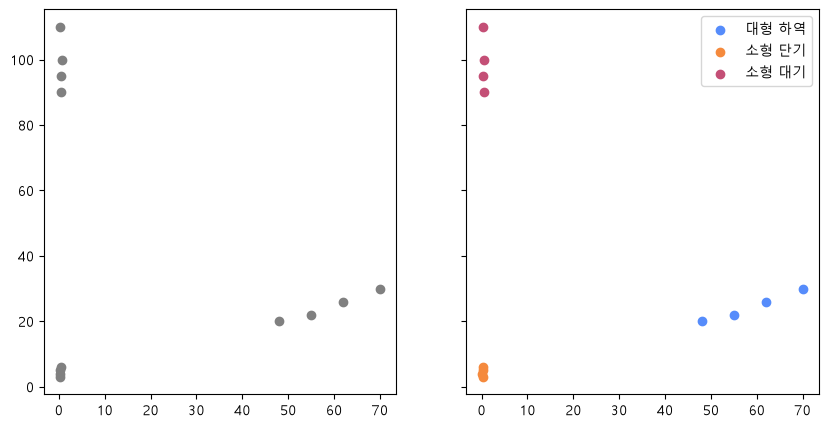

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

axes[0].scatter(toy['총톤수'], toy['체류시간'], color='gray')

for group, part  in toy.groupby('군집'):
    axes[1].scatter(part['총톤수'], part['체류시간'], label=group)

axes[1].legend()

fig.show()

# 좋은 군집의 조건

군집화를 하기 위한 방법은 여러가지가 있다. 확정적인 정답은 없지만, 좋은 군집이되기 위한 조건은 있다.

- 같은 군집 안의 점들은 서로서로 가까워야 된다. (응집도, Cohesion)
- 다른 군집끼리는 멀리 떨어져 있어야 된다. (분리도, Separation)




# 분류(Classification)와 군집(Clustering)

분류는 이미 아는 구분을 자동으로 붙이는 일에 사용되는 개념이고, 군집 아직 모르는 구분을 발견하는 일에 사용된다.

- 분류: 정답 이름표가 달린 데이터를 구분짓는 것
- 군집: 값만 있는 상태에서 데이터들을 모아보는 것


## 군집분석의 절차

1. 질문 결정
2. 변수 선택
3. 전처리
4. 알고리즘 및 K 설정
5. 해석
6. 검증 및 활용


### 변수 선택과 군집화

군집분석에서는 '비슷하다'를 기준으로 군집화를 수행하는데, 어떤 변수를 기준으로 했는가에 따라서 결과가 달라질 수 있다.

몇 건의 데이터가 있는데, 변수를 총톤수만 넣으면 '큰배/작은배', 체류시간만 넣으면 '오래있는배/금방가는배'

운영에서 구분하고 싶은 차이를 결정한다음 변수를 설정하는것이 중요하다. 변수 선택 자체가 분석자의 판단이 들어갔다.


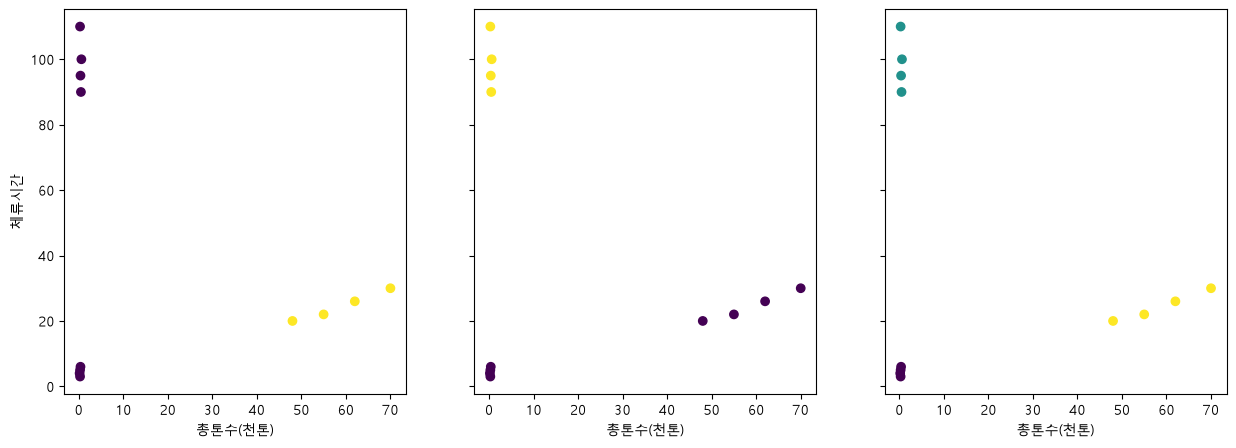

In [14]:
from sklearn.cluster import KMeans

variable_sets = {
    '총톤수': (['총톤수'], 2), # k=2
    '체류시간': (['체류시간'], 2), # k=2
    '총톤수+체류시간': (['총톤수', '체류시간'], 3), # k=3
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, ( title, (col, k) ) in zip(axes, variable_sets.items()):
    labels = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(toy[col])
    ax.scatter(toy['총톤수'], toy['체류시간'], c=labels)
    ax.set_xlabel('총톤수(천톤)')

axes[0].set_ylabel('체류시간')

plt.show()


In [16]:
toy.groupby('군집')[['총톤수', '체류시간']].mean()

,총톤수,체류시간
군집,,
대형 하역,58.75,24.50
소형 단기,0.30,4.50
소형 대기,0.45,98.75


In [20]:
TAGET_DATA = '입출항_집계정보'

d004 = load_dataset(TAGET_DATA)
d004 = d004[['선박종류명', '총톤수', '입항일시', '출항일시', '적재톤수', '양하톤수']]

d004.shape

(272904, 6)

In [21]:
d004.info()

<class 'pandas.DataFrame'>
RangeIndex: 272904 entries, 0 to 272903
Data columns (total 6 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   선박종류명   272894 non-null  str    
 1   총톤수     272467 non-null  float64
 2   입항일시    272904 non-null  str    
 3   출항일시    272904 non-null  str    
 4   적재톤수    270645 non-null  float64
 5   양하톤수    270644 non-null  float64
dtypes: float64(3), str(3)
memory usage: 12.5 MB


In [22]:
d004.head(3)

,선박종류명,총톤수,입항일시,출항일시,적재톤수,양하톤수
0,풀컨테이너선,18334.0,2019-10-17 14:00,2019-10-18 14:00,6773.0,6773.0
1,LPG 운반선,3345.0,2019-10-15 19:00,2019-10-16 10:00,0.0,0.0
2,일반화물선,2398.0,2019-10-14 06:00,2019-10-14 16:00,4093.0,4093.0


In [23]:
d004['입항'] = pd.to_datetime(d004['입항일시'], format='%Y-%m-%d %H:%M', errors='coerce')
d004['출항'] = pd.to_datetime(d004['출항일시'], format='%Y-%m-%d %H:%M', errors='coerce')

In [24]:
d004.info()

<class 'pandas.DataFrame'>
RangeIndex: 272904 entries, 0 to 272903
Data columns (total 8 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   선박종류명   272894 non-null  str           
 1   총톤수     272467 non-null  float64       
 2   입항일시    272904 non-null  str           
 3   출항일시    272904 non-null  str           
 4   적재톤수    270645 non-null  float64       
 5   양하톤수    270644 non-null  float64       
 6   입항      272904 non-null  datetime64[us]
 7   출항      272904 non-null  datetime64[us]
dtypes: datetime64[us](2), float64(3), str(3)
memory usage: 16.7 MB


In [25]:
d004['체류시간'] = (d004['출항'] - d004['입항']).dt.total_seconds() / 3600
d004['화물톤'] = d004['적재톤수'] + d004['양하톤수']

In [35]:
rules = {
    '기간 밖 입항': ~d004['입항'].dt.year.between(2019, 2024),
    '체류 음수,30분 미만': d004['체류시간'] < 0.5,
    '총톤수 0 이하,결측': ~(d004['총톤수'] > 0),
    '화물톤 결측': d004['화물톤'].isna(),
    '화물톤 > 총톤수': d004['화물톤'] > d004['총톤수'] * 10,
}

for name, mask in rules.items():
    print(f'{name} = {mask.sum()}건')

drop = pd.concat(rules, axis=1).any(axis=1)
vessels = d004[~drop].copy()

vessels

기간 밖 입항 = 43건
체류 음수,30분 미만 = 8116건
총톤수 0 이하,결측 = 470건
화물톤 결측 = 2260건
화물톤 > 총톤수 = 1260건


,선박종류명,총톤수,입항일시,출항일시,적재톤수,양하톤수,입항,출항,체류시간,화물톤
0,풀컨테이너선,18334.0,2019-10-17 14:00,2019-10-18 14:00,6773.0,6773.0,2019-10-17 14:00:00,2019-10-18 14:00:00,24.000000,13546.0
1,LPG 운반선,3345.0,2019-10-15 19:00,2019-10-16 10:00,0.0,0.0,2019-10-15 19:00:00,2019-10-16 10:00:00,15.000000,0.0
2,일반화물선,2398.0,2019-10-14 06:00,2019-10-14 16:00,4093.0,4093.0,2019-10-14 06:00:00,2019-10-14 16:00:00,10.000000,8186.0
3,석유제품 운반선,200.0,2019-09-26 15:50,2019-10-08 05:35,0.0,0.0,2019-09-26 15:50:00,2019-10-08 05:35:00,277.750000,0.0
4,세미(혼재)컨테이너선,13682.0,2019-06-26 20:00,2019-06-27 12:00,313.0,313.0,2019-06-26 20:00:00,2019-06-27 12:00:00,16.000000,626.0
...,...,...,...,...,...,...,...,...,...,...
272897,견인용예선,49.0,2023-12-23 11:15,2023-12-27 06:45,0.0,0.0,2023-12-23 11:15:00,2023-12-27 06:45:00,91.500000,0.0
272898,기타 예선,19.0,2023-09-11 11:38,2023-09-11 12:37,0.0,0.0,2023-09-11 11:38:00,2023-09-11 12:37:00,0.983333,0.0
272899,기타 예선,19.0,2023-09-11 13:05,2023-09-19 15:25,0.0,0.0,2023-09-11 13:05:00,2023-09-19 15:25:00,194.333333,0.0
272900,기타 예선,19.0,2023-11-03 08:37,2023-12-04 08:54,0.0,0.0,2023-11-03 08:37:00,2023-12-04 08:54:00,744.283333,0.0


In [36]:
vessels['선박종류명'].value_counts()

선박종류명
풀컨테이너선         78388
석유제품 운반선       62590
일반화물선          22392
견인용예선          19416
기타 예선          10912
산물선(벌크선)       10386
기타 유조선          8043
원양 어선           7264
여객선             7190
급유선             6318
냉동.냉장선          5617
기타선             5283
케미칼 운반선         4414
세미(혼재)컨테이너선     2971
시멘트운반선          1987
국제카페리           1829
원유운반선           1492
LPG 운반선         1309
자동차운반선           969
철강재 운반선          630
관공선              529
크루즈선             367
모래운반선            265
이.접안용 예선         207
LNG 운반선          203
압항 예선            170
군함               126
케미칼가스 운반선         95
용달선               77
폐기물 운반선           32
연근해 어선            27
수상레저기구            25
유람선               17
석탄운반선             13
준설선               12
원목운반선             12
신조선               10
화객선                9
코일전용선              4
핫코일운반선             3
예부선                2
광목운반선              1
통선                 1
기타 부선              1
Name: count, dtype: int64

In [38]:
top_vessels = vessels['선박종류명'].value_counts().head(6)

top = vessels[vessels['선박종류명'].isin(top_vessels.index)]
quartiles = top.groupby('선박종류명')[['총톤수', '체류시간', '화물톤']].quantile([0.25, 0.5, 0.75]).unstack().round(0)

quartiles

총톤수                    체류시간                  화물톤           \
            0.25     0.50     0.75  0.25  0.50   0.75    0.25     0.50   
선박종류명                                                                    
견인용예선       54.0     80.0     99.0   9.0  32.0  103.0     0.0      0.0   
기타 예선       46.0     79.0    137.0   6.0  27.0  106.0     0.0      0.0   
산물선(벌크선)  4416.0  22918.0  36300.0   7.0  13.0   35.0     0.0    400.0   
석유제품 운반선   181.0    438.0    919.0  10.0  28.0   68.0     0.0      0.0   
일반화물선     1725.0   2997.0   5549.0   7.0  18.0   49.0     0.0   1382.0   
풀컨테이너선    9522.0  17518.0  54809.0  14.0  20.0   29.0  5010.0  11951.0   

                   
             0.75  
선박종류명              
견인용예선         0.0  
기타 예선         0.0  
산물선(벌크선)  13400.0  
석유제품 운반선   1400.0  
일반화물선      4897.0  
풀컨테이너선    35480.0

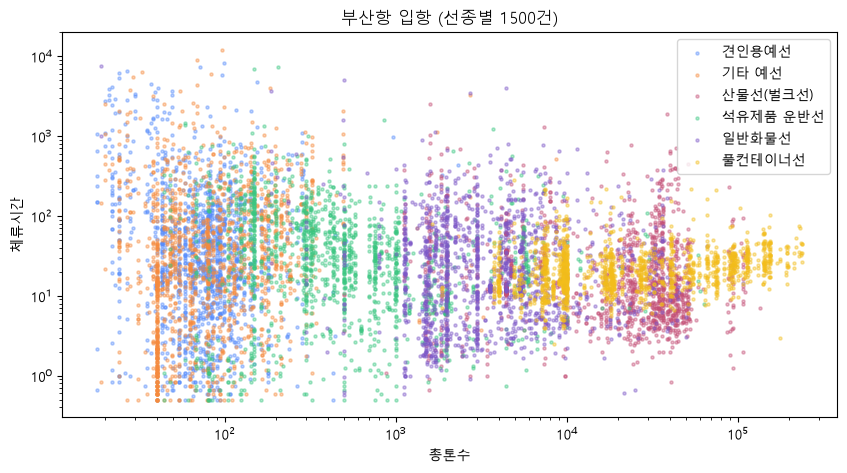

In [49]:
type_sample = top.groupby('선박종류명', group_keys=False).sample(1500, random_state=55)

fig, ax = plt.subplots(figsize=(10, 5))

for name, part in type_sample.groupby('선박종류명'):
    ax.scatter(part['총톤수'], part['체류시간'], s=5, alpha=0.4, label=name)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_title('부산항 입항 (선종별 1500건)')
ax.set_xlabel('총톤수')
ax.set_ylabel('체류시간')

ax.legend()

plt.show()

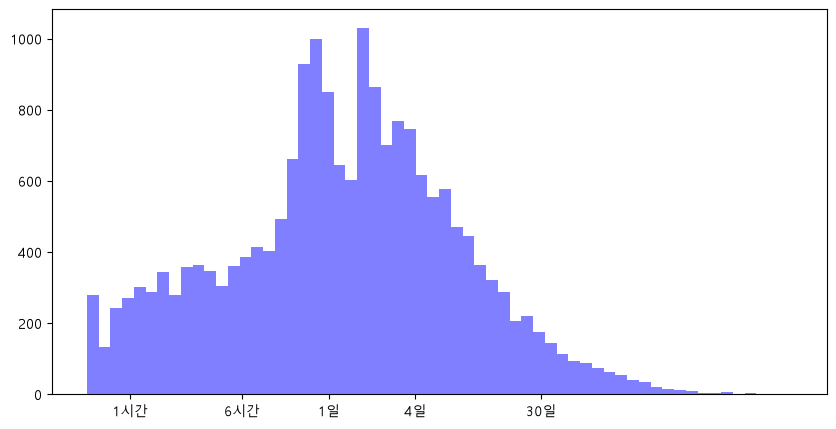

In [47]:
stay = vessels.loc[vessels['선박종류명'] == '견인용예선', '체류시간']

bins = [ 0, 6, 12, 24, 48, 96, 720 ]

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(np.log10(stay), bins=60, color='blue', alpha=0.5)
ax.set_xticks(np.log10([1, 6, 24, 96, 720]), ['1시간', '6시간', '1일', '4일', '30일'])

plt.show()


체류시간 구간별 비율을 확인하면 1일,  4일 초과가 양쪽 끝으로 몰려있고, 가운데는 상대적으로 적다. 봉우리가 2개 식별이 되는데 이렇게 봉우리가 두개인 분포를 쌍봉 분포(Bimodal Distribution)이라고 일컫고, 이는 곧 서로 다른 두 무리가 한 이름아래 섞여있다는 대표적인 신호이다.

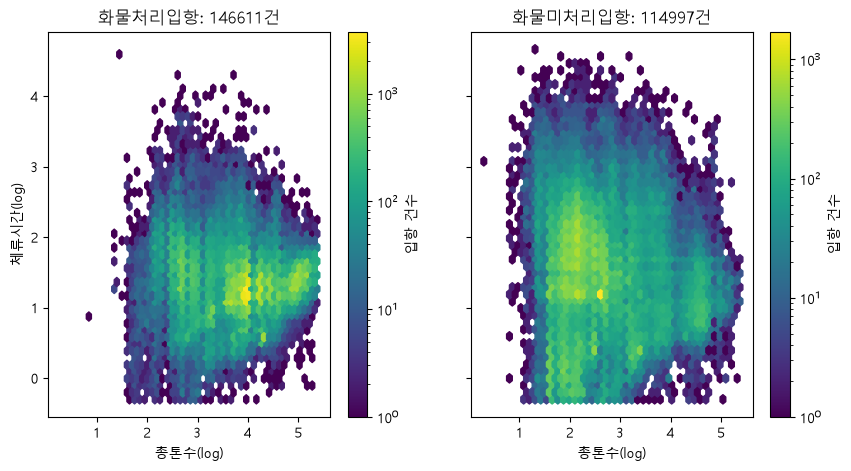

In [56]:
has_cargo = vessels['화물톤'] > 0

# 육각밀도그림(Hexbin plot)
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

for ax, mask, name in [ ( axes[0], has_cargo, '화물처리입항' ), ( axes[1], ~has_cargo, '화물미처리입항' ) ]:
    part = vessels[mask]

    hb = ax.hexbin(
        np.log10(part['총톤수']),
        np.log10(part['체류시간']),
        bins='log',
        gridsize=45,
    )

    ax.set_title(f'{name}: {mask.sum()}건')
    ax.set_xlabel('총톤수(log)')

    fig.colorbar(hb, ax=ax, label='입항 건수')

axes[0].set_ylabel('체류시간(log)')

plt.show()